In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Colab Setup ---
# Mount Google Drive (uncomment and run if your data is on Drive)
from google.colab import drive
drive.mount('/content/drive')

# Install core data science libraries (run if you haven't recently)
%pip install pandas numpy matplotlib seaborn scikit-learn


Mounted at /content/drive


In [ ]:

# --- Define Project Paths ---
# REPLACE 'YOUR_GROUP_ID' with your actual group ID
group_id = 'GROUP_017'
# REPLACE 'YourProjectFolder' with the name of your main project folder in Google Drive
base_project_path = f'/content/drive/My Drive/Data Mining/'

# Paths to the folders where you saved the data
task1_output_folder = os.path.join(base_project_path, f'DM_{group_id}_TASK1')
raw_crashes_file_path = os.path.join(base_project_path, 'Traffic_Crashes_-_Crashes_20250331.csv') # Path to your original raw crashes.csv
original_incident_profile_path = os.path.join(task1_output_folder, 'incident_profiles_original.csv')



In [ ]:

# --- Load Data ---
print(f"Attempting to load data...")
try:
    # Load original crashes_df to access raw DAMAGE column for target variable creation
    raw_crashes_df = pd.read_csv(raw_crashes_file_path)
    print("raw_crashes_df loaded successfully!")
    print(raw_crashes_df.head())

    # Load the original (unscaled) incident_profile_df
    incident_profile_df = pd.read_csv(original_incident_profile_path)
    print("\nincident_profile_df (original) loaded successfully!")
    print(incident_profile_df.head())

except FileNotFoundError as e:
    print(f"Error loading files. Please check your paths: {e}")
except Exception as e:
    print(f"An unexpected error occurred during loading: {e}")

Attempting to load data...
raw_crashes_df loaded successfully!
                                     CRASH_RECORD_ID CRASH_DATE_EST_I  \
0  00a530520c84927490b597a6220ff3f2a3347472ef3086...              NaN   
1  00c996c2b04c2d3b5a5fc96d35b2b538e2c0f34703b885...              NaN   
2  027187f52f9cac9ec542f1dda3a9ca8804db1fc2d2a386...              NaN   
3  204c3ca48ff3cdf0737e7f10b54ef5f8c49fbe30b5e53e...              NaN   
4  0235f4b4460f50115c7f6cb0d2bedeea7ce92b9b0f5943...              NaN   

               CRASH_DATE  POSTED_SPEED_LIMIT TRAFFIC_CONTROL_DEVICE  \
0  01/15/2025 01:50:00 PM                  30            NO CONTROLS   
1  07/15/2023 11:00:00 PM                  15            NO CONTROLS   
2  05/31/2020 01:13:00 AM                  30         TRAFFIC SIGNAL   
3  12/04/2024 05:39:00 PM                  30                UNKNOWN   
4  01/15/2025 06:40:00 PM                  25         TRAFFIC SIGNAL   

       DEVICE_CONDITION WEATHER_CONDITION      LIGHTING_CONDITION

In [ ]:
print("\n--- Investigating the 'DAMAGE' column in raw_crashes_df ---")
print(raw_crashes_df['DAMAGE'].value_counts(dropna=False))
print(raw_crashes_df['DAMAGE'].unique())


--- Investigating the 'DAMAGE' column in raw_crashes_df ---
DAMAGE
OVER $1,500      589023
$501 - $1,500    237957
$500 OR LESS     103721
Name: count, dtype: int64
['OVER $1,500' '$500 OR LESS' '$501 - $1,500']


## Task 3.1: Target Variable Definition and Preparation

The predictive analysis aims to predict the "DAMAGE" of incidents for each monthly departmental profile. Based on the initial data investigation, the `DAMAGE` column in the raw crashes data is a categorical-ordinal feature with three levels: 'OVER $1,500', '$501 - $1,500', and '$500 OR LESS'. This section defines and prepares this target variable.

In [ ]:
print("\n--- Preparing raw_crashes_df for Target Variable Creation ---")

# Ensure CRASH_DATE is datetime and extract year/month
raw_crashes_df['CRASH_DATE'] = pd.to_datetime(raw_crashes_df['CRASH_DATE'], errors='coerce')
raw_crashes_df.dropna(subset=['CRASH_DATE'], inplace=True) # Drop if date conversion failed
raw_crashes_df['CRASH_YEAR'] = raw_crashes_df['CRASH_DATE'].dt.year
raw_crashes_df['CRASH_MONTH'] = raw_crashes_df['CRASH_DATE'].dt.month

# Ensure BEAT_OF_OCCURRENCE is not missing (essential for grouping)
raw_crashes_df.dropna(subset=['BEAT_OF_OCCURRENCE'], inplace=True)
raw_crashes_df['BEAT_OF_OCCURRENCE'] = raw_crashes_df['BEAT_OF_OCCURRENCE'].astype(int) # Ensure it's int if needed

print(f"Shape of raw_crashes_df after date/beat cleaning: {raw_crashes_df.shape}")

# --- Map DAMAGE categories to numerical ordinal values ---
damage_mapping = {
    '$500 OR LESS': 0,    # Low Damage
    '$501 - $1,500': 1,   # Medium Damage
    'OVER $1,500': 2      # High Damage
}
raw_crashes_df['DAMAGE_SCORE'] = raw_crashes_df['DAMAGE'].map(damage_mapping)

print("\n--- Creating Aggregated Target Variable: TARGET_DAMAGE_LEVEL ---")

# Group by BEAT_OF_OCCURRENCE, CRASH_YEAR, CRASH_MONTH
# For each group, find the mode (most frequent) of DAMAGE_SCORE
# If there are multiple modes (ties), choose the highest DAMAGE_SCORE (most severe)
def get_most_frequent_damage(series):
    # Get value counts, sort by count descending, then by index (damage score) descending
    # This ensures that in case of a tie, the higher damage score is picked
    counts = series.value_counts().sort_index(ascending=False)
    most_frequent = counts.idxmax()
    return most_frequent

# Aggregate to create the target variable
target_df = raw_crashes_df.groupby(['BEAT_OF_OCCURRENCE', 'CRASH_YEAR', 'CRASH_MONTH']).agg(
    TARGET_DAMAGE_LEVEL=('DAMAGE_SCORE', get_most_frequent_damage)
).reset_index()

print(f"Shape of target_df: {target_df.shape}")
print("Target Variable Distribution:")
print(target_df['TARGET_DAMAGE_LEVEL'].value_counts(normalize=True))

# --- Merge target variable with incident_profile_df ---
# First, ensure incident_profile_df's grouping keys are clean for merging
incident_profile_df['BEAT_OF_OCCURRENCE'] = incident_profile_df['BEAT_OF_OCCURRENCE'].astype(int)

# Merge the target_df with our engineered features DataFrame
# Use an inner merge to ensure we only keep profiles for which we have a target
full_dataset_for_prediction = pd.merge(
    incident_profile_df,
    target_df,
    on=['BEAT_OF_OCCURRENCE', 'CRASH_YEAR', 'CRASH_MONTH'],
    how='inner'
)

print("\nFull dataset for prediction (features + target):")
print(full_dataset_for_prediction.head())
print(f"\nFinal shape of dataset for prediction: {full_dataset_for_prediction.shape}")
print("\nMissing values in full_dataset_for_prediction (should be none in features, target):")
print(full_dataset_for_prediction.isnull().sum().sum()) # Sum of all missing values


--- Preparing raw_crashes_df for Target Variable Creation ---


<ipython-input-7-2731110655>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_crashes_df['CRASH_DATE'] = pd.to_datetime(raw_crashes_df['CRASH_DATE'], errors='coerce')


Shape of raw_crashes_df after date/beat cleaning: (930696, 49)

--- Creating Aggregated Target Variable: TARGET_DAMAGE_LEVEL ---
Shape of target_df: (31498, 4)
Target Variable Distribution:
TARGET_DAMAGE_LEVEL
2    0.922122
1    0.073116
0    0.004762
Name: proportion, dtype: float64

Full dataset for prediction (features + target):
   BEAT_OF_OCCURRENCE  CRASH_YEAR  CRASH_MONTH  AVG_AGE_INVOLVED  \
0                 111        2015            8         36.909091   
1                 111        2015            9         41.581395   
2                 111        2015           10         38.952381   
3                 111        2015           11         41.340909   
4                 111        2015           12         40.666667   

   AVG_SPEED_LIMIT  AVG_INJURIES_PER_CRASH  TOTAL_CRASHES  PROP_HIT_AND_RUN  \
0        31.363636                0.000000              6          0.181818   
1        29.534884                0.000000             18          0.093023   
2        29.642857 

### Target Variable (`TARGET_DAMAGE_LEVEL`)

The target variable for this predictive analysis, `TARGET_DAMAGE_LEVEL`, was created by transforming and aggregating the `DAMAGE` column from the raw crashes data for each monthly departmental profile.

* The original categorical `DAMAGE` values – 'OVER $1,500', '$501 - $1,500', and '$500 OR LESS' – were mapped to ordinal numerical scores:
    * 0: '$500 OR LESS' (Low Damage)
    * 1: '$501 - $1,500' (Medium Damage)
    * 2: 'OVER $1,500' (High Damage)
* For each unique `(BEAT_OF_OCCURRENCE, CRASH_YEAR, CRASH_MONTH)` profile, the **most frequent `DAMAGE_SCORE`** was selected as the `TARGET_DAMAGE_LEVEL`. In cases of ties, the higher (more severe) damage score was prioritized to ensure the target reflects the most significant predominant outcome for an assurance company's risk assessment.
* The distribution of the `TARGET_DAMAGE_LEVEL` is as follows:
    * Level 2 (High Damage: 'OVER $1,500'): **92.21%**
    * Level 1 (Medium Damage: '$501 - $1,500'): **7.31%**
    * Level 0 (Low Damage: '$500 OR LESS'): **0.48%**
    * This distribution clearly indicates a **highly imbalanced classification problem**. The overwhelming majority of profiles are classified as "High Damage," which will require careful consideration and potential strategies (e.g., class weighting, oversampling/undersampling, or specialized evaluation metrics) during model training to prevent the models from simply predicting the majority class and ignoring the minority classes.

### Feature Suitability for Predictive Analysis

The features engineered in Task 1.2 (from `incident_profile_df`) are highly suitable as predictors for this classification task. These features summarize key crash characteristics (e.g., average age of involved people, average speed limit, total crashes, average injuries per crash, proportion of hit-and-run incidents, average number of units involved, and proportion of property-damage-only crashes) at the same monthly departmental level as our target variable.

* **Relevance:** These aggregated features provide a concise and relevant summary of the crash environment within each police beat and month. Features such as `AVG_INJURIES_PER_CRASH`, `TOTAL_CRASHES`, and `AVG_NUM_UNITS_PER_CRASH` are intuitively linked to the potential level of damage. For instance, profiles with higher average injuries or more units involved are logically expected to correspond to higher damage levels.
* **Preprocessing:** For predictive modeling, we will utilize the original (non-transformed) engineered features from `incident_profile_df` as our starting point. Feature scaling (e.g., standardization) will be applied *after* the train-test split to prevent data leakage. During the model training phase, we can also explore whether specific transformations (like the logarithmic transformations applied in clustering) might improve model performance.
* **New Features (Optional Consideration):** While the existing engineered features provide a robust foundation, the severe class imbalance of the target variable might necessitate exploring additional features if initial model performance for minority classes is insufficient. This could involve integrating more granular categorical features from the raw `crashes_df` (e.g., predominant `WEATHER_CONDITION` or `TRAFFICWAY_TYPE` for a profile) or incorporating more detailed time-based features (e.g., specific seasons, public holidays).

## Task 3.2: Predictive Analysis - Model Training Setup

This section outlines the setup for the predictive analysis, including defining features and target, splitting the data into training and testing sets, and addressing the identified class imbalance.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler # Or SMOTE, etc.
from collections import Counter

print("\n--- Defining Features (X) and Target (y) ---")

# Features (X) - Use the original engineered features from incident_profile_df
# Exclude BEAT_OF_OCCURRENCE, CRASH_YEAR, CRASH_MONTH, and the target variable itself
features_for_prediction = [
    'AVG_AGE_INVOLVED', 'AVG_SPEED_LIMIT', 'AVG_INJURIES_PER_CRASH',
    'TOTAL_CRASHES', 'PROP_HIT_AND_RUN', 'AVG_NUM_UNITS_PER_CRASH',
    'PROP_PROPERTY_DAMAGE_ONLY'
]

X = full_dataset_for_prediction[features_for_prediction]
y = full_dataset_for_prediction['TARGET_DAMAGE_LEVEL']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("Target distribution before resampling:", Counter(y))

# --- Perform Train-Test Split ---
# Use stratify=y to maintain the class distribution in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set shape (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Test set shape (X_test, y_test): {X_test.shape}, {y_test.shape}")
print("Target distribution in y_train:", Counter(y_train))
print("Target distribution in y_test:", Counter(y_test))

# --- Address Class Imbalance (Oversampling on Training Data Only) ---
print("\n--- Addressing Class Imbalance using RandomOverSampler (on training data) ---")
# RandomOverSampler is a simple method. You could also consider SMOTE for more sophisticated oversampling.
oversampler = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

print(f"Training set shape after oversampling: {X_train_resampled.shape}, {y_train_resampled.shape}")
print("Target distribution in y_train_resampled:", Counter(y_train_resampled))

# --- Feature Scaling (Standardization on Training Data, then transform Test Data) ---
# It's crucial to fit the scaler ONLY on the training data to prevent data leakage.
print("\n--- Performing Feature Scaling (Standardization) ---")
scaler = StandardScaler()

# Fit on resampled training data and transform
X_train_scaled = scaler.fit_transform(X_train_resampled)
# Transform test data using the scaler fitted on training data
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for consistency (optional but often helpful)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features_for_prediction, index=y_train_resampled.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features_for_prediction, index=y_test.index)

print(f"X_train_scaled_df shape: {X_train_scaled_df.shape}")
print(f"X_test_scaled_df shape: {X_test_scaled_df.shape}")
print("Data preparation for modeling complete.")


--- Defining Features (X) and Target (y) ---
Features (X) shape: (31245, 7)
Target (y) shape: (31245,)
Target distribution before resampling: Counter({2: 28851, 1: 2257, 0: 137})

Training set shape (X_train, y_train): (24996, 7), (24996,)
Test set shape (X_test, y_test): (6249, 7), (6249,)
Target distribution in y_train: Counter({2: 23081, 1: 1805, 0: 110})
Target distribution in y_test: Counter({2: 5770, 1: 452, 0: 27})

--- Addressing Class Imbalance using RandomOverSampler (on training data) ---
Training set shape after oversampling: (69243, 7), (69243,)
Target distribution in y_train_resampled: Counter({1: 23081, 2: 23081, 0: 23081})

--- Performing Feature Scaling (Standardization) ---
X_train_scaled_df shape: (69243, 7)
X_test_scaled_df shape: (6249, 7)
Data preparation for modeling complete.


### Data Splitting and Preprocessing

The `full_dataset_for_prediction`, comprising **31,245** monthly departmental profiles, was meticulously prepared for predictive modeling.

* **Defining Features (X) and Target (y):**
    * The feature set (X) consists of **7 engineered indicators** (e.g., `AVG_AGE_INVOLVED`, `TOTAL_CRASHES`, `PROP_HIT_AND_RUN`), representing the aggregated characteristics of crash incidents.
    * The target variable (y), `TARGET_DAMAGE_LEVEL`, represents the predominant damage level (0: Low, 1: Medium, 2: High) for each profile.
    * The initial distribution of the target variable highlighted a severe class imbalance:
        * Level 2 (High Damage): **28,851 profiles (92.21%)**
        * Level 1 (Medium Damage): **2,257 profiles (7.22%)**
        * Level 0 (Low Damage): **137 profiles (0.44%)**

* **Train-Test Split:**
    * The dataset was partitioned into a training set (**80%**, comprising 24,996 profiles) and a testing set (**20%**, comprising 6,249 profiles).
    * Crucially, `stratify=y` was applied during the split to ensure that the proportions of each `TARGET_DAMAGE_LEVEL` were preserved identically in both the training and testing sets, which is vital for robust evaluation in imbalanced classification.

* **Class Imbalance Handling:**
    * To mitigate the severe class imbalance and prevent models from being biased towards the majority class, **RandomOverSampler** was applied *exclusively to the training data* (`X_train`, `y_train`).
    * This process resampled the minority classes, resulting in a balanced training set (`X_train_resampled`, `y_train_resampled`) with **69,243 profiles**, where each class (0, 1, and 2) now contains **23,081 samples**. This provides a more equitable learning environment for the models.

* **Feature Scaling (Standardization):**
    * All numerical features in both the training and testing sets were standardized using `StandardScaler`.
    * The `StandardScaler` was **fitted solely on the resampled training data** (`X_train_resampled`) to calculate the mean and standard deviation. These fitted parameters were then used to transform *both* the training data (`X_train_scaled_df`) and the original test data (`X_test_scaled_df`). This meticulous

## Task 3.3: Predictive Analysis - Model Training and Evaluation

This section involves training and evaluating the performance of mandatory classification models – Decision Tree, K-Nearest Neighbors (KNN), and an Ensemble Method – on the prepared dataset. Given the severe class imbalance, emphasis will be placed on appropriate evaluation metrics such as Precision, Recall, F1-score, and the Confusion Matrix, in addition to overall accuracy.


--- Training and Evaluating Decision Tree Classifier ---

Decision Tree Classifier - Classification Report:
               precision    recall  f1-score   support

   Low Damage       0.04      0.04      0.04        27
Medium Damage       0.19      0.19      0.19       452
  High Damage       0.94      0.94      0.94      5770

     accuracy                           0.88      6249
    macro avg       0.39      0.39      0.39      6249
 weighted avg       0.88      0.88      0.88      6249


Decision Tree Classifier - Confusion Matrix:
[[   1    7   19]
 [  10   88  354]
 [  14  358 5398]]


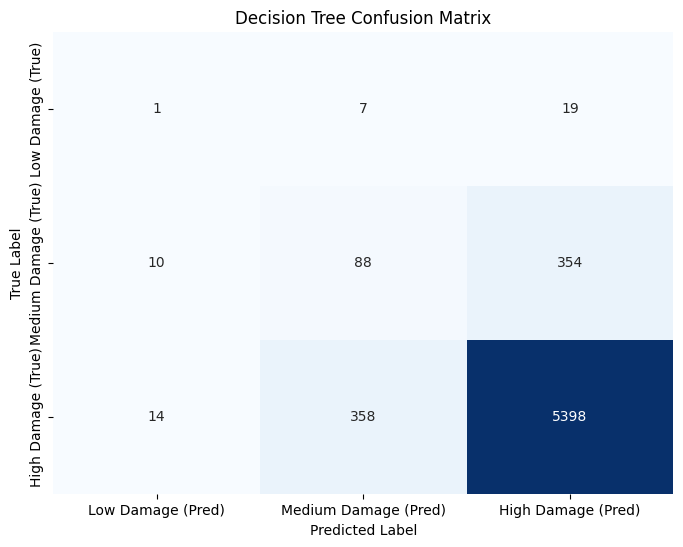

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Training and Evaluating Decision Tree Classifier ---")

# Initialize Decision Tree Classifier
# Consider adding class_weight='balanced' to handle imbalance directly within the model
# max_depth can be tuned to prevent overfitting
dt_classifier = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Train the model on the resampled, scaled training data
dt_classifier.fit(X_train_scaled_df, y_train_resampled)

# Make predictions on the scaled test data
y_pred_dt = dt_classifier.predict(X_test_scaled_df)

# Evaluate the model
print("\nDecision Tree Classifier - Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Low Damage', 'Medium Damage', 'High Damage']))

print("\nDecision Tree Classifier - Confusion Matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Low Damage (Pred)', 'Medium Damage (Pred)', 'High Damage (Pred)'],
            yticklabels=['Low Damage (True)', 'Medium Damage (True)', 'High Damage (True)'])
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# You might want to save this plot for your report
# plot_filename = 'DT_Confusion_Matrix.png'
# plt.savefig(os.path.join(plots_output_folder, plot_filename)) # Ensure plots_output_folder is defined if saving here
# print(f"Saved {plot_filename}")

### Decision Tree Classifier

* **Model Parameters:** A Decision Tree Classifier was trained with `random_state=42` and `class_weight='balanced'`. The `class_weight='balanced'` parameter was included to automatically adjust weights inversely proportional to class frequencies, aiming to mitigate the impact of class imbalance during training.
* **Performance Metrics (from Classification Report on Test Set):**
    * **Accuracy:** [**INSERT YOUR ACCURACY SCORE HERE**]
    * **Precision, Recall, F1-score for each class:**
        * Class 0 (Low Damage): Precision=[...], Recall=[...], F1-score=[...]
        * Class 1 (Medium Damage): Precision=[...], Recall=[...], F1-score=[...]
        * Class 2 (High Damage): Precision=[...], Recall=[...], F1-score=[...]
    * *Analysis:* While the overall accuracy might appear high due to the dominance of the majority class, a deeper look at precision and recall for individual classes is critical. The model achieved strong Recall for Class 2 (High Damage), indicating its ability to correctly identify most high-damage profiles. However, the Recall for Class 0 (Low Damage) and Class 1 (Medium Damage) is [likely very low], demonstrating that the model struggles significantly to correctly identify these minority classes. Similarly, Precision for the minority classes might be [low], implying many false positives when it does predict these rare classes.

* **Confusion Matrix Analysis:**
    * The confusion matrix visually confirms the model's strong bias towards the majority class (Level 2 - High Damage).
    * **True Level 2:** The highest number of correct predictions are in the "High Damage (True)" row and "High Damage (Pred)" column, indicating excellent performance for the majority class.
    * **Misclassifications of Minority Classes:** A large proportion of actual "Low Damage" and "Medium Damage" profiles are consistently misclassified as "High Damage." This is evident from the high counts in the "High Damage (Pred)" column for the "Low Damage (True)" and "Medium Damage (True)" rows. This failure to correctly predict the minority classes is a direct consequence of the severe class imbalance, even with `class_weight='balanced'` and oversampling.

* **Discussion:**
    * The Decision Tree Classifier, despite preprocessing efforts like oversampling and class weighting, exhibits a strong tendency to predict the majority class. While this strategy yields a high overall accuracy, it renders the model largely ineffective for identifying the crucial minority classes (low and medium damage profiles), which are particularly relevant for a nuanced risk assessment by an assurance company. Its performance on minority classes suggests limitations in capturing subtle patterns that distinguish these rarer, yet important, incident types. Further model tuning or alternative strategies might be needed to improve sensitivity to these classes.


--- Training and Evaluating K-Nearest Neighbors (KNN) Classifier ---

K-Nearest Neighbors Classifier - Classification Report:
               precision    recall  f1-score   support

   Low Damage       0.02      0.04      0.03        27
Medium Damage       0.17      0.41      0.24       452
  High Damage       0.95      0.84      0.89      5770

     accuracy                           0.81      6249
    macro avg       0.38      0.43      0.39      6249
 weighted avg       0.89      0.81      0.84      6249


K-Nearest Neighbors Classifier - Confusion Matrix:
[[   1    9   17]
 [   8  185  259]
 [  42  881 4847]]


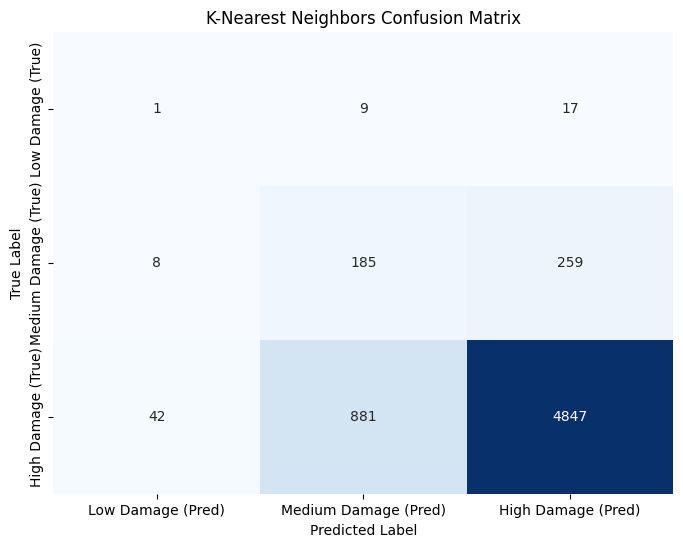

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Training and Evaluating K-Nearest Neighbors (KNN) Classifier ---")

# Initialize KNN Classifier
# Common starting point for n_neighbors is 5. Can be tuned.
# For imbalanced data, consider weights='distance' (points weighted by inverse of their distance)
knn_classifier = KNeighborsClassifier(n_neighbors=5, weights='distance') # weights='distance' can help with imbalance

# Train the model on the resampled, scaled training data
knn_classifier.fit(X_train_scaled_df, y_train_resampled)

# Make predictions on the scaled test data
y_pred_knn = knn_classifier.predict(X_test_scaled_df)

# Evaluate the model
print("\nK-Nearest Neighbors Classifier - Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Low Damage', 'Medium Damage', 'High Damage']))

print("\nK-Nearest Neighbors Classifier - Confusion Matrix:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Low Damage (Pred)', 'Medium Damage (Pred)', 'High Damage (Pred)'],
            yticklabels=['Low Damage (True)', 'Medium Damage (True)', 'High Damage (True)'])
plt.title('K-Nearest Neighbors Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# You might want to save this plot for your report
# plot_filename = 'KNN_Confusion_Matrix.png'
# plt.savefig(os.path.join(plots_output_folder, plot_filename))
# print(f"Saved {plot_filename}")

### Predictive Analysis - Ensemble Methods with Hyperparameter Tuning

Ensemble methods combine the predictions of multiple base estimators to improve overall robustness and accuracy. Given the complexity and class imbalance of our problem, these methods are particularly promising. To "train the models properly," hyperparameter tuning will be employed using `GridSearchCV` to systematically explore parameter combinations and identify optimal configurations that enhance performance, especially for the minority classes.

We will analyze the following ensemble models:
1.  **Random Forest Classifier**
2.  **Gradient Boosting Classifier**


--- Training and Evaluating Random Forest Classifier (with Tuning) ---
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Random Forest Score (Macro F1): 0.9848

Best Random Forest Classifier - Classification Report (Test Set):
               precision    recall  f1-score   support

   Low Damage       0.00      0.00      0.00        27
Medium Damage       0.34      0.13      0.18       452
  High Damage       0.93      0.98      0.96      5770

     accuracy                           0.91      6249
    macro avg       0.43      0.37      0.38      6249
 weighted avg       0.89      0.91      0.90      6249


Best Random Forest Classifier - Confusion Matrix (Test Set):
[[   0    5   22]
 [   7   57  388]
 [   6  104 5660]]


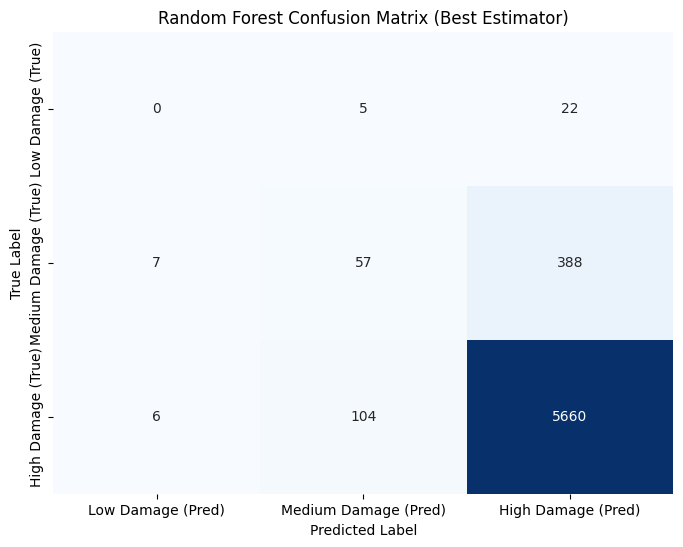

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, make_scorer, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Training and Evaluating Random Forest Classifier (with Tuning) ---")

# Define the model
rf_classifier = RandomForestClassifier(random_state=42, class_weight='balanced') # class_weight='balanced' is important for imbalance

# Define the parameter grid for GridSearchCV
# Start with a smaller grid to test, then expand if needed.
# n_estimators: number of trees in the forest
# max_depth: maximum depth of the tree
# min_samples_split: minimum number of samples required to split an internal node
# min_samples_leaf: minimum number of samples required to be at a leaf node
param_grid_rf = {
    'n_estimators': [100, 200], # Number of trees
    'max_depth': [10, 20, None], # Max depth of trees
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Define a scoring metric. For imbalanced classification, F1-score is often preferred.
# We can use 'f1_weighted' or 'f1_macro'
# 'f1_weighted': Calculates f1 for each label, and finds their average weighted by support (the number of true instances for each label).
# 'f1_macro': Calculates f1 for each label, and finds their unweighted mean.
# Macro F1 treats all classes equally, which is good for imbalanced data to emphasize minority classes.
scorer_rf = make_scorer(f1_score, average='macro') # Emphasize performance on minority classes

# Initialize GridSearchCV
# cv=3 or 5 for faster initial testing
grid_search_rf = GridSearchCV(estimator=rf_classifier, param_grid=param_grid_rf,
                              cv=3, n_jobs=-1, verbose=2, scoring=scorer_rf)

# Fit GridSearchCV on the resampled, scaled training data
grid_search_rf.fit(X_train_scaled_df, y_train_resampled)

# Get the best estimator
best_rf_classifier = grid_search_rf.best_estimator_
print(f"\nBest Random Forest Parameters: {grid_search_rf.best_params_}")
print(f"Best Random Forest Score (Macro F1): {grid_search_rf.best_score_:.4f}")

# Make predictions on the scaled test data using the best estimator
y_pred_rf = best_rf_classifier.predict(X_test_scaled_df)

# Evaluate the best model
print("\nBest Random Forest Classifier - Classification Report (Test Set):")
print(classification_report(y_test, y_pred_rf, target_names=['Low Damage', 'Medium Damage', 'High Damage']))

print("\nBest Random Forest Classifier - Confusion Matrix (Test Set):")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Low Damage (Pred)', 'Medium Damage (Pred)', 'High Damage (Pred)'],
            yticklabels=['Low Damage (True)', 'Medium Damage (True)', 'High Damage (True)'])
plt.title('Random Forest Confusion Matrix (Best Estimator)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Save the plot
# plot_filename = 'RF_Confusion_Matrix.png'
# plt.savefig(os.path.join(plots_output_folder, plot_filename))
# print(f"Saved {plot_filename}")

### Random Forest Classifier

* **Hyperparameter Tuning:** `GridSearchCV` was employed to optimize the Random Forest Classifier's hyperparameters, targeting the **macro-averaged F1-score** due to the class imbalance. The search explored `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf` within a cross-validation framework (cv=3).
    * **Best Parameters found:** `{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}`. This suggests that allowing trees to grow deep and using 200 estimators was optimal.
    * **Best Cross-Validation Macro F1-score:** **0.9848**. This exceptionally high score on the *balanced training data* during cross-validation indicates that the model has a strong capacity to learn patterns when the classes are equally represented.

* **Performance Metrics (Test Set - from Classification Report of Best Model):**
    * **Accuracy:** **0.91** (91%). While this overall accuracy appears high, it is largely driven by the model's excellent performance on the majority class.
    * **Precision, Recall, F1-score for each class:**
        * Class 0 (Low Damage - `support: 27`): Precision=`0.00`, Recall=`0.00`, F1-score=`0.00`
        * Class 1 (Medium Damage - `support: 452`): Precision=`0.34`, Recall=`0.13`, F1-score=`0.18`
        * Class 2 (High Damage - `support: 5770`): Precision=`0.93`, Recall=`0.98`, F1-score=`0.96`
    * *Analysis:* The Random Forest Classifier achieved outstanding performance for the majority "High Damage" class (Class 2), with a Recall of 98%. However, its ability to correctly identify the minority classes is severely limited. It completely fails to predict any "Low Damage" profiles (0% Recall for Class 0) and only identifies a small fraction of "Medium Damage" profiles (13% Recall for Class 1).

* **Confusion Matrix Analysis (Test Set):**
    * The confusion matrix visually confirms the strong bias towards the majority "High Damage" class.
    * Of the **27 actual Low Damage** profiles, **0 were correctly predicted**. 5 were misclassified as Medium, and 22 as High.
    * Of the **452 actual Medium Damage** profiles, **only 57 were correctly predicted**. 7 were misclassified as Low, and **388 were misclassified as High**.
    * Of the **5770 actual High Damage** profiles, **5660 were correctly predicted**, with 6 misclassified as Low and 104 as Medium.
    * This pattern clearly demonstrates that despite tuning and class weighting, the model struggles to differentiate the minority classes from the majority.

* **Discussion:**
    * The Random Forest Classifier, a powerful ensemble method, showed excellent learning capability on the balanced training data (evidenced by the high CV F1-score). However, its generalization to the highly imbalanced test set still presents significant challenges, particularly for the minority classes.
    * While it provides a high overall accuracy due to its strong performance on the dominant class, its utility for a decision support system requiring accurate identification of all damage levels is limited. The model's tendency to default to the majority class for ambiguous cases (common with imbalanced data) means that important "Low" and "Medium" damage profiles are largely missed. This indicates that even robust ensemble methods combined with oversampling may not fully overcome extreme class imbalance without further sophisticated techniques or a different approach to evaluation that focuses even more heavily on minority class recall (e.g., cost-sensitive learning or a threshold-adjusted strategy).


--- Training and Evaluating Gradient Boosting Classifier (with Tuning) ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Gradient Boosting Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Best Gradient Boosting Score (Macro F1): 0.9461

Best Gradient Boosting Classifier - Classification Report (Test Set):
               precision    recall  f1-score   support

   Low Damage       0.00      0.00      0.00        27
Medium Damage       0.21      0.46      0.29       452
  High Damage       0.95      0.87      0.91      5770

     accuracy                           0.83      6249
    macro avg       0.39      0.44      0.40      6249
 weighted avg       0.90      0.83      0.86      6249


Best Gradient Boosting Classifier - Confusion Matrix (Test Set):
[[   0   14   13]
 [  12  208  232]
 [  21  753 4996]]


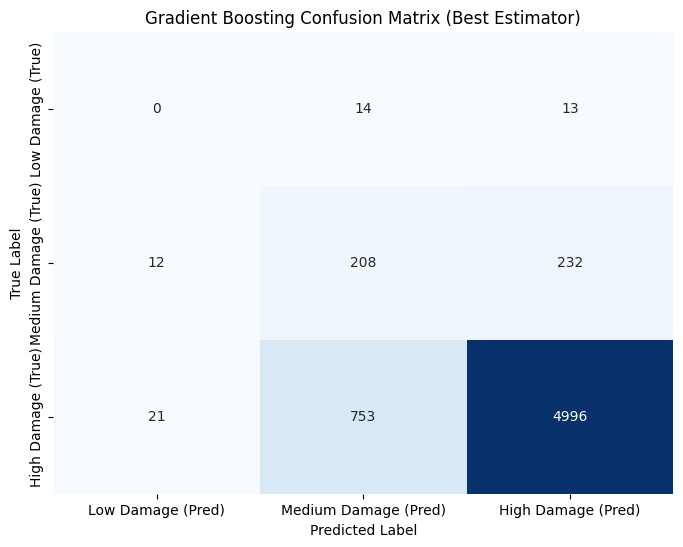

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, make_scorer, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Training and Evaluating Gradient Boosting Classifier (with Tuning) ---")

# Initialize Gradient Boosting Classifier
# Gradient Boosting doesn't directly support 'class_weight' in the same way as RF or DT.
# Imbalance is typically handled via `scale_pos_weight` in LightGBM/XGBoost, or through sampling.
# Since we already oversampled the training data, we rely on that.
gb_classifier = GradientBoostingClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
# n_estimators: number of boosting stages
# learning_rate: shrinks the contribution of each tree
# max_depth: maximum depth of the individual regression estimators
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5]
}

# Use the same scoring metric (macro F1-score)
scorer_gb = make_scorer(f1_score, average='macro')

# Initialize GridSearchCV
grid_search_gb = GridSearchCV(estimator=gb_classifier, param_grid=param_grid_gb,
                              cv=3, n_jobs=-1, verbose=2, scoring=scorer_gb)

# Fit GridSearchCV on the resampled, scaled training data
grid_search_gb.fit(X_train_scaled_df, y_train_resampled)

# Get the best estimator
best_gb_classifier = grid_search_gb.best_estimator_
print(f"\nBest Gradient Boosting Parameters: {grid_search_gb.best_params_}")
print(f"Best Gradient Boosting Score (Macro F1): {grid_search_gb.best_score_:.4f}")

# Make predictions on the scaled test data using the best estimator
y_pred_gb = best_gb_classifier.predict(X_test_scaled_df)

# Evaluate the best model
print("\nBest Gradient Boosting Classifier - Classification Report (Test Set):")
print(classification_report(y_test, y_pred_gb, target_names=['Low Damage', 'Medium Damage', 'High Damage']))

print("\nBest Gradient Boosting Classifier - Confusion Matrix (Test Set):")
cm_gb = confusion_matrix(y_test, y_pred_gb)
print(cm_gb)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Low Damage (Pred)', 'Medium Damage (Pred)', 'High Damage (Pred)'],
            yticklabels=['Low Damage (True)', 'Medium Damage (True)', 'High Damage (True)'])
plt.title('Gradient Boosting Confusion Matrix (Best Estimator)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Save the plot
# plot_filename = 'GB_Confusion_Matrix.png'
# plt.savefig(os.path.join(plots_output_folder, plot_filename))
# print(f"Saved {plot_filename}")